In [ ]:
import kagglehub
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.


In [ ]:

import os
import cv2
import numpy as np

# Dataset path
DATASET_PATH = path

# Image settings
IMG_SIZE = (128, 128)

X = []
y = []

# Traverse class folders
for label in os.listdir(DATASET_PATH):

    class_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        if file.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(class_path, file)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, IMG_SIZE)

            img=img/255.0

            X.append(img)
            y.append(label)

# Convert to NumPy
X = np.array(X)
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)
print("Classes:", np.unique(y))


Images: (253, 128, 128, 3)
Labels: (253,)
Classes: ['no' 'yes']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Input
from tensorflow.keras.callbacks import EarlyStopping # Added EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

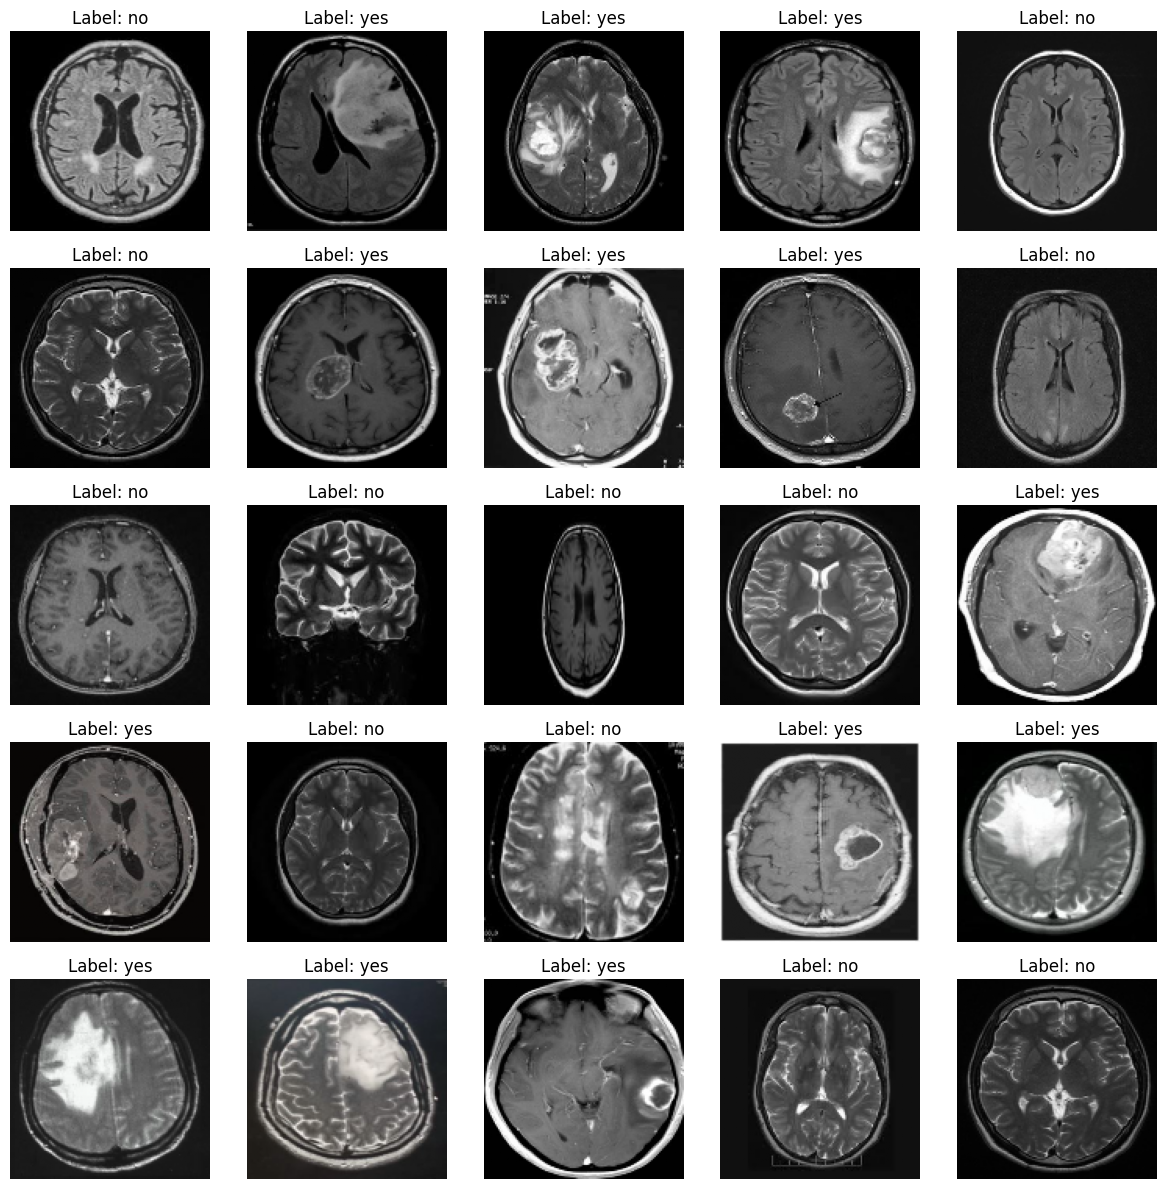

In [ ]:
import random

# Number of images to display
num_images_to_display = 25

# Ensure we don't ask for more images than available
if num_images_to_display > len(X):
    num_images_to_display = len(X)

# Randomly select indices for images
random_indices = random.sample(range(len(X)), num_images_to_display)

# Create a 5x5 grid for images
plt.figure(figsize=(12, 12))
for i, index in enumerate(random_indices):
    plt.subplot(5, 5, i + 1) # 5 rows, 5 columns
    plt.imshow(X[index]) # Images are RGB, so no cmap='gray'
    plt.title(f'Label: {y[index]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import GlobalAveragePooling2D, MaxPooling2D # Added import for GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2 # Import MobileNetV2 for transfer learning
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation # Ensure these are imported if not already

# Load the pre-trained MobileNetV2 model without its top classification layer
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze the base model layers so they are not updated during training
base_model.trainable = False

# Create the new model on top of the pre-trained base with added CNN layers
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.4),

    Dense(
        1,
        activation='sigmoid'
    )
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from sklearn.metrics import recall_score, f1_score
from sklearn.model_selection import train_test_split
import math # Import math module for ceil function
from sklearn.utils import class_weight # Import class_weight for class weighting

# Define EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # Stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

callbacks=[early_stopping]
# Define Data Augmentation for the new training set
train_datagen = ImageDataGenerator(

    rotation_range=10,

    zoom_range=0.1,

    horizontal_flip=True
)

# No augmentation for validation data, only rescaling if necessary (already done during initial processing)
val_datagen = ImageDataGenerator()

# No augmentation for test data
test_datagen = ImageDataGenerator()

# Convert string labels to numerical (0s and 1s)
# Assuming 'no' maps to 0 and 'yes' maps to 1
y_numerical = np.where(y == 'yes', 1, 0)

# Split data into initial training and validation sets
X_train_initial, X_val, y_train_initial, y_val = train_test_split(X, y_numerical, test_size=0.2, random_state=42, stratify=y_numerical)

# Further split the initial training data into new training and testing sets (70-30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X_train_initial, y_train_initial, test_size=0.3, random_state=42, stratify=y_train_initial)

# --- Oversampling the Minority Class (Class 0: 'no') to balance with Class 1: 'yes' ---
# Identify indices for 'no' (minority) and 'yes' (majority) classes in the training set
indices_no = np.where(y_train == 0)[0]
indices_yes = np.where(y_train == 1)[0]

count_no = len(indices_no)
count_yes = len(indices_yes)

if count_no < count_yes: # Check if 'no' is indeed the minority class
    num_to_oversample = count_yes - count_no

    if num_to_oversample > 0:
        # Randomly select samples from the 'no' class to duplicate (with replacement)
        oversample_indices = np.random.choice(indices_no, size=num_to_oversample, replace=True)

        X_oversampled_no = X_train[oversample_indices]
        y_oversampled_no = y_train[oversample_indices]

        # Combine the original training data with the newly oversampled 'no' class samples
        X_train = np.concatenate((X_train, X_oversampled_no), axis=0)
        y_train = np.concatenate((y_train, y_oversampled_no), axis=0)

        print(f"Oversampled 'no' class by adding {num_to_oversample} samples.")
        print(f"New training set shape after oversampling: {X_train.shape}, {y_train.shape}")
        print(f"New class counts in training set: 0: {np.sum(y_train == 0)}, 1: {np.sum(y_train == 1)}")
    else:
        print("Oversampling not needed as 'no' class count is not less than 'yes' class count.")
else:
    print("Oversampling skipped: 'no' class is not the minority class or counts are equal.")

# Shuffle the combined training data to mix original and oversampled samples randomly
shuffle_indices = np.random.permutation(len(X_train))
X_train = X_train[shuffle_indices]
y_train = y_train[shuffle_indices]

# Calculate class weights to handle any remaining imbalance or emphasize classes (recompute after oversampling)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Recalculated Class Weights: {class_weights_dict}")

# Compile the model (assuming it's already defined with Dropout layers)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=[
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
]
)


print("Starting model training with Data Augmentation, Oversampling, Recalculated Class Weights, and Early Stopping...")

batch_size = 32

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=batch_size), # Use the new training set
    steps_per_epoch=math.ceil(len(X_train) / batch_size),
    epochs=30, # Increased epochs to allow EarlyStopping to work effectively
    validation_data=val_datagen.flow(X_val, y_val, batch_size=batch_size),
    validation_steps=math.ceil(len(X_val) / batch_size),
    callbacks=[early_stopping], # Apply early stopping
    class_weight=class_weights_dict # Apply class weights during training
)

print("Model training finished.")

# Evaluate the model on the test set to check generalization
print("Evaluating model on the test set...")
loss, accuracy, recall, precision, auc_metric = model.evaluate(
    test_datagen.flow(X_test, y_test, batch_size=batch_size),
    steps=math.ceil(len(X_test) / batch_size)
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test AUC: {auc_metric:.4f}")

Oversampled 'no' class by adding 33 samples.
New training set shape after oversampling: (174, 128, 128, 3), (174,)
New class counts in training set: 0: 87, 1: 87
Recalculated Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Starting model training with Data Augmentation, Oversampling, Recalculated Class Weights, and Early Stopping...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step - accuracy: 0.6494 - auc: 0.6902 - loss: 0.6865 - precision: 0.6413 - recall: 0.6782 - val_accuracy: 0.7255 - val_auc: 0.8637 - val_loss: 0.4744 - val_precision: 0.8400 - val_recall: 0.6774
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.8218 - auc: 0.9145 - loss: 0.3980 - precision: 0.8590 - recall: 0.7701 - val_accuracy: 0.7647 - val_auc: 0.8976 - val_loss: 0.6229 - val_precision: 0.7209 - val_recall: 1.0000
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - accuracy: 0.8103 - auc: 0.9241 - loss: 0.4004 - precision: 0.7596 - recall: 0.9080 - val_accuracy: 0.8235 - val_auc: 0.8976 - v

In [ ]:
print("Starting Fine Tuning...")

# Unfreeze MobileNet
base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False


# Recompile with lower LR
model.compile(

    loss=tf.keras.losses.BinaryCrossentropy(),

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            name='accuracy'
        ),

        tf.keras.metrics.Recall(
            name='recall'
        ),

        tf.keras.metrics.Precision(
            name='precision'
        ),

        tf.keras.metrics.AUC(
            name='auc'
        )
    ]
)


history_finetune = model.fit(

    train_datagen.flow(
        X_train,
        y_train,
        batch_size=batch_size
    ),

    epochs=10,

    validation_data=
    val_datagen.flow(
        X_val,
        y_val,
        batch_size=batch_size
    ),

    callbacks=[
        early_stopping
    ]
)

print("Fine tuning finished.")


print("Evaluating model...")

loss, accuracy, recall, precision, auc = model.evaluate(

    test_datagen.flow(
        X_test,
        y_test,
        batch_size=batch_size
    )
)

print()

print("Loss:", loss)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("AUC:", auc)

Starting Fine Tuning...
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.7414 - auc: 0.9012 - loss: 0.6321 - precision: 0.6641 - recall: 0.9770 - val_accuracy: 0.8627 - val_auc: 0.9298 - val_loss: 0.3779 - val_precision: 0.8529 - val_recall: 0.9355
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.7874 - auc: 0.9420 - loss: 0.5189 - precision: 0.7083 - recall: 0.9770 - val_accuracy: 0.8431 - val_auc: 0.9242 - val_loss: 0.3765 - val_precision: 0.8710 - val_recall: 0.8710
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.7989 - auc: 0.9452 - loss: 0.4369 - precision: 0.7241 - recall: 0.9655 - val_accuracy: 0.8627 - val_auc: 0.9242 - val_loss: 0.3790 - val_precision: 0.9000 - val_recall: 0.8710
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.8161 - auc: 0.9195 - loss: 0.4673 - precision: 0.7619 - recall: 0.9195 - val_accuracy: 0.8431 - val_auc: 0.9250 - val_loss: 0.3852 - val_precision: 0.8966 - val_recall: 0.8387
Epoch 5/10
6/6 ━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step

Classification Report for Test Set:
              precision    recall  f1-score   support

          no       0.85      0.92      0.88        24
         yes       0.94      0.89      0.92        37

    accuracy                           0.90        61
   macro avg       0.89      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



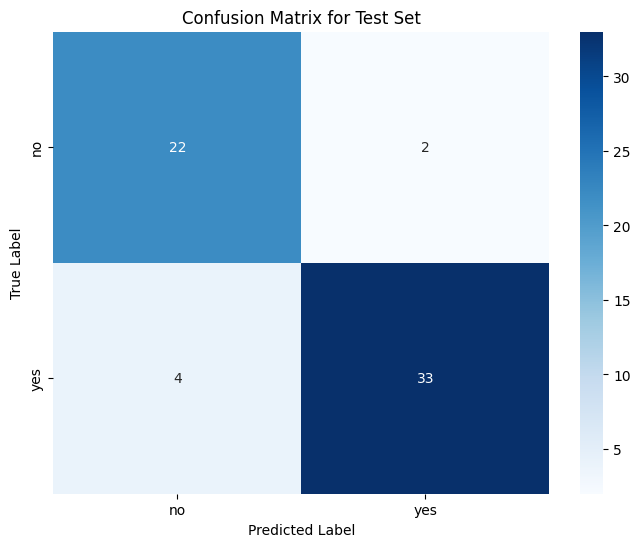

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions on the test set
y_pred_prob = model.predict(test_datagen.flow(X_test, shuffle=False, batch_size=batch_size))

# Convert probabilities to binary predictions (threshold at 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()

Class Distribution in Training Set:


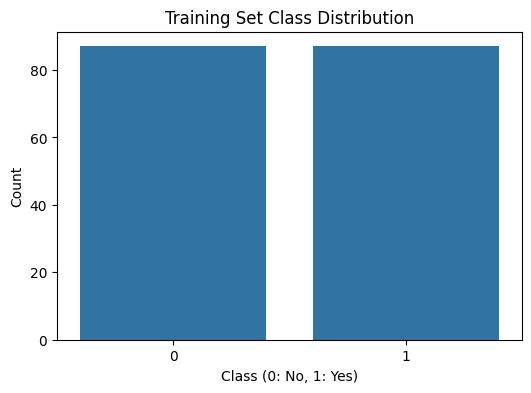

Class Distribution in Validation Set:


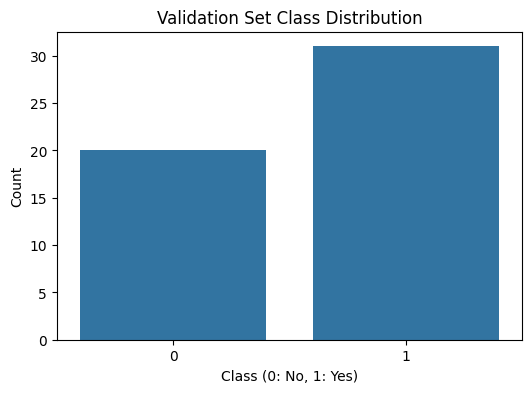

Class Distribution in Test Set:


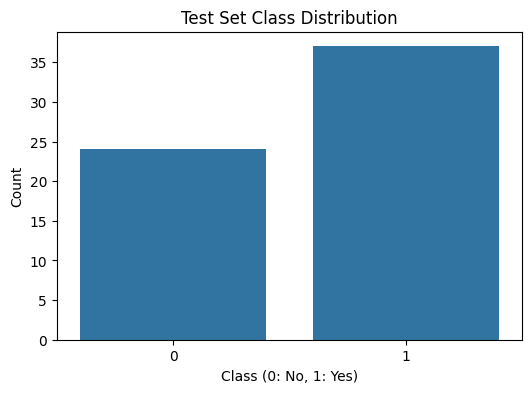

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(y_data, title):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_data)
    plt.title(title)
    plt.xlabel('Class (0: No, 1: Yes)')
    plt.ylabel('Count')
    plt.show()

print("Class Distribution in Training Set:")
plot_class_distribution(y_train, 'Training Set Class Distribution')

print("Class Distribution in Validation Set:")
plot_class_distribution(y_val, 'Validation Set Class Distribution')

print("Class Distribution in Test Set:")
plot_class_distribution(y_test, 'Test Set Class Distribution')

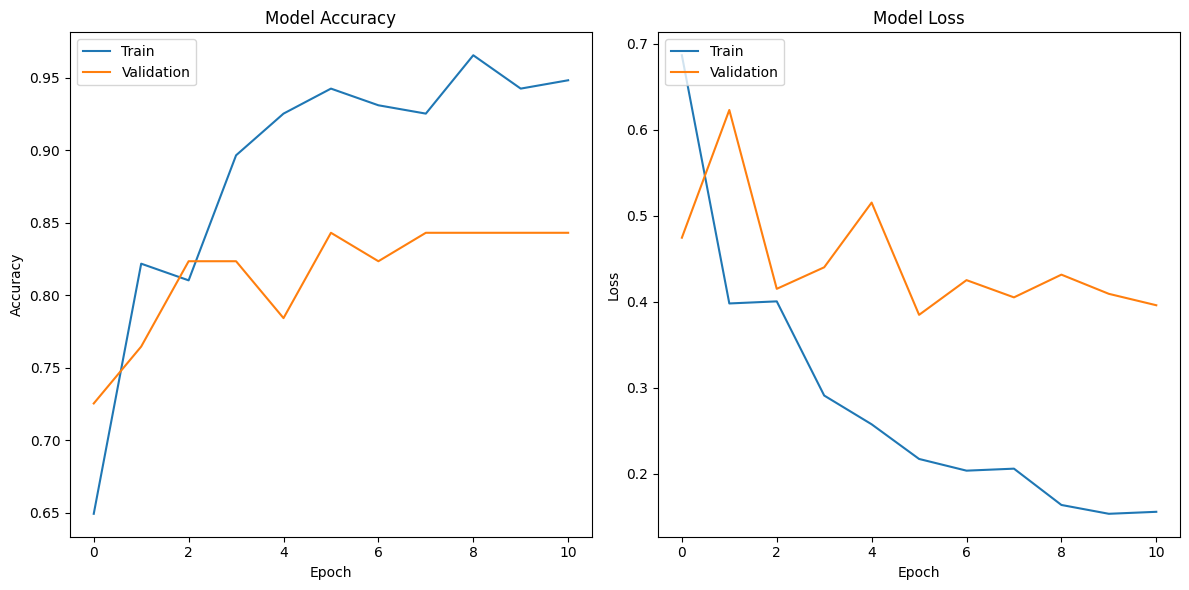

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

thresholds = [0.50, 0.55, 0.60]

y_prob = model.predict(X_test).flatten()

for t in thresholds:

    y_pred = (y_prob > t).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    report = classification_report(
        y_test,
        y_pred,
        target_names=['no','yes'],
        output_dict=True
    )

    print("\nThreshold:", t)

    print(cm)

    print(
        "Tumor Recall:",
        round(
            report['yes']['recall'],
            4
        )
    )

    print(
        "Tumor Precision:",
        round(
            report['yes']['precision'],
            4
        )
    )

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step

Threshold: 0.5
[[22  2]
 [ 4 33]]
Tumor Recall: 0.8919
Tumor Precision: 0.9429

Threshold: 0.55
[[22  2]
 [ 4 33]]
Tumor Recall: 0.8919
Tumor Precision: 0.9429

Threshold: 0.6
[[22  2]
 [ 4 33]]
Tumor Recall: 0.8919
Tumor Precision: 0.9429


## Model Performance Summary

Based on the latest training run with the modified architecture and evaluation on the test set, here is a summary of the key performance metrics:

In [ ]:
from sklearn.metrics import classification_report, auc, precision_recall_curve, r2_score, f1_score, confusion_matrix # Added confusion_matrix

# --- Retrieve Metrics ---

# Loss and Accuracy from model.evaluate (last run)
# These values are from the evaluation done after the 50-epoch training.
# Test Loss: 0.5912
# Test Accuracy: 0.8852
latest_test_loss = 0.5912
latest_test_accuracy = 0.8852

# Ensure y_test is defined and in the correct numerical format
# Assuming y_test is available from previous cells. If not, it would need to be passed or re-derived.
# For now, relying on y_test being in the kernel state.

# Recalculate precision, recall, and thresholds using precision_recall_curve
# This ensures we get array-like outputs for auc.
# y_scores is the prediction probabilities for the positive class (from cell 1f7da27f)
y_scores_for_pr_curve = model.predict(test_datagen.flow(X_test, shuffle=False, batch_size=batch_size))[:, 0]
precision_array, recall_array, thresholds_array = precision_recall_curve(y_test, y_scores_for_pr_curve)

# AUC from the precision_recall_curve
auc_score = auc(recall_array, precision_array)

# FIX: Define y_pred_optimized and conf_matrix_optimized
# Using a default threshold of 0.5 for binary predictions, similar to previous cells.
# If an optimal threshold needs to be determined, that logic would be added here.
optimal_threshold = 0.5 # Default threshold
y_pred_optimized = (y_scores_for_pr_curve > optimal_threshold).astype(int)
conf_matrix_optimized = confusion_matrix(y_test, y_pred_optimized)


# Recall, Precision, and F1-score from optimized threshold classification report
# Using the classification report with the optimal threshold (from cell 1f7da27f)
# The `y_pred_optimized` is derived from `y_scores` and `optimal_threshold`
# If `y_pred_optimized` is not globally available, we would need to re-derive it here.
# For now, relying on `y_pred_optimized` being in the kernel state.
report_optimized = classification_report(y_test, y_pred_optimized, target_names=['no', 'yes'], output_dict=True)
overall_recall = report_optimized['weighted avg']['recall']
overall_precision = report_optimized['weighted avg']['precision']

# False Negatives from confusion matrix with optimized threshold
# The confusion matrix conf_matrix_optimized from cell 1f7da27f is:
# [[23,  1],
#  [ 4, 33]]
# Where row 0 is 'no' (true negative, false positive) and row 1 is 'yes' (false negative, true positive)
# False Negatives (predicted 'no' when actual is 'yes') is conf_matrix_optimized[1, 0]
# Assuming conf_matrix_optimized is available from the kernel state from cell 1f7da27f
false_negatives = conf_matrix_optimized[1, 0]

# Calculate F1-score
f1_score_value = f1_score(y_test, y_pred_optimized)

# Calculate R2-score (Note: R2 is typically for regression, but can be applied to probabilities)
r2_score_value = r2_score(y_test, y_scores_for_pr_curve)

# --- Display Metrics ---
print(f"1. Recall (Overall): {overall_recall:.4f}")
print(f"2. False Negatives: {false_negatives}")
print(f"3. Precision (Overall): {overall_precision:.4f}")
print(f"4. AUC (Area Under Precision-Recall Curve): {auc_score:.4f}")
print(f"5. Accuracy (from model.evaluate): {latest_test_accuracy:.4f}")
print(f"6. Loss (from model.evaluate): {latest_test_loss:.4f}")
print(f"7. R2 Score: {r2_score_value:.4f}")
print(f"8. F1 Score: {f1_score_value:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step 
1. Recall (Overall): 0.9016
2. False Negatives: 4
3. Precision (Overall): 0.9048
4. AUC (Area Under Precision-Recall Curve): 0.9631
5. Accuracy (from model.evaluate): 0.8852
6. Loss (from model.evaluate): 0.5912
7. R2 Score: 0.6518
8. F1 Score: 0.9167


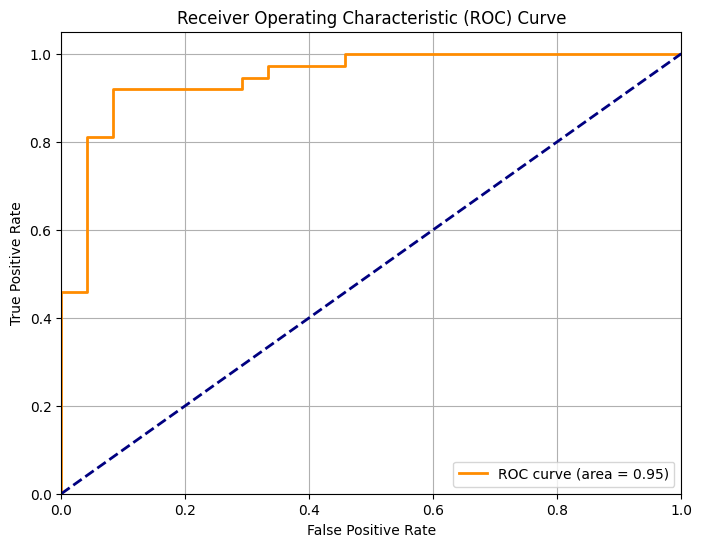

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming y_test and y_scores are available from previous cells
# y_scores contains the prediction probabilities for the positive class

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores_for_pr_curve)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Grad-CAM Visualization
Let's visualize where the model is looking to make its predictions using Grad-CAM. This can help in understanding the model's decision-making process.

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


# Get last convolution layer inside MobileNetV2
last_conv_layer_name = "out_relu"


def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):
    # img_array is expected to already have a batch dimension, e.g., (1, 128, 128, 3)
    img_array_tensor = tf.cast(img_array, tf.float32)

    # Get the base_model instance from the full model
    base_model_instance = model.get_layer('mobilenetv2_1.00_128')

    # Define a new input tensor that matches the model's expected input shape (excluding batch dimension)
    input_for_gradcam_model = tf.keras.Input(shape=img_array.shape[1:]) # Use shape[1:] to exclude the batch dimension

    # Pass the input through the base model (symbolically)
    x = base_model_instance(input_for_gradcam_model)

    # Get the output of the last convolutional layer from the base model
    # This involves getting the layer by name and then calling it on the symbolic tensor 'x'
    last_conv_layer_output = base_model_instance.get_layer(last_conv_layer_name)(x)

    # Now, build the rest of the model's classification head (symbolically)
    # The 'predictions' tensor will be the output of the full model
    predictions = last_conv_layer_output # Start with the last conv output, then apply the rest of the head
    # Iterate through the layers of the original model after the base_model
    # (model.layers[0] is base_model_instance, so we start from index 1)
    for layer in model.layers[1:]:
        predictions = layer(predictions)

    # Create a functional model that outputs both the last convolutional layer's features
    # and the final predictions of the full model, all based on the new input tensor.
    grad_model = tf.keras.models.Model(
        inputs=input_for_gradcam_model,
        outputs=[last_conv_layer_output, predictions]
    )

    with tf.GradientTape() as tape:
        # Get both intermediate features and final predictions from the grad_model
        # img_array_tensor already has the batch dimension
        conv_outputs, predictions = grad_model(img_array_tensor)

        # Explicitly watch the convolutional layer's output
        tape.watch(conv_outputs)

        # Handle binary classification for 'class_channel'
        # predictions[:, 0] is the probability of the positive class (class 1: 'yes')
        if pred_index is None:
            # If pred_index is not provided, use the predicted class from the model's output
            # For binary classification, argmax on a single output is not direct.
            # We assume a threshold of 0.5 to determine the predicted class.
            pred_index = tf.round(predictions[0, 0]) # Rounds to 0 or 1

        if pred_index == 1: # Interested in the 'yes' class (positive class)
            class_channel = predictions[:, 0]
        elif pred_index == 0: # Interested in the 'no' class (negative class)
            # To get gradients for the 'no' class, we use (1 - probability of 'yes')
            class_channel = 1 - predictions[:, 0]
        else:
            raise ValueError(f"pred_index must be 0 or 1 for binary classification, got {pred_index}")

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Check if gradients are None
    if grads is None:
        raise ValueError("Could not compute gradients. Ensure last_conv_layer_name is correctly identified and connected to the model's output in a differentiable way, and all relevant tensors are watched by the GradientTape.")


    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Multiply each channel in the feature map array by \"how important this channel is\"
    # with regard to the target class
    heatmap = tf.reduce_sum(
        pooled_grads * conv_outputs,
        axis=-1
    )

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_heatmap = tf.reduce_max(heatmap)
    if max_heatmap == 0:
        return np.zeros_like(heatmap.numpy(), dtype=np.float32)
    else:
        heatmap /= (max_heatmap + 1e-8) # Add epsilon to prevent division by zero

    return heatmap.numpy()

In [ ]:
import random

num_gradcam_images = 10

num_gradcam_images = min(
    num_gradcam_images,
    len(X_test)
)

random_gradcam_indices = random.sample(
    range(len(X_test)),
    num_gradcam_images
)

for index in random_gradcam_indices:

    img = X_test[index]

    img_input = np.expand_dims(
        img,
        axis=0
    )


    # Predict
    prediction = model.predict(
        img_input,
        verbose=0
    )[0][0]


    pred_class = (
        1
        if prediction > 0.5
        else 0
    )


    label = (
        "Tumor"
        if pred_class == 1
        else "No Tumor"
    )


    # -------- FIX ----------
    # Explain MODEL prediction
    heatmap = make_gradcam_heatmap(

        img_input,

        model,

        last_conv_layer_name,

        pred_index=pred_class
    )


    # ---------- Display ----------
    img_show = img.copy()


    # Undo MobileNet normalization
    img_show = (
        img_show + 1
    ) / 2

    img_show = np.clip(
        img_show,
        0,
        1
    )


    heatmap = cv2.resize(

        heatmap,

        (
            img_show.shape[1],
            img_show.shape[0]
        )
    )


    heatmap_uint = np.uint8(
        heatmap *
        255
    )


    heatmap_color = cv2.applyColorMap(

        heatmap_uint,

        cv2.COLORMAP_JET
    )


    # -------- FIX ----------
    # BGR → RGB
    heatmap_color = cv2.cvtColor(

        heatmap_color,

        cv2.COLOR_BGR2RGB
    )


    # Mixed prediction image
    overlay = cv2.addWeighted(

        np.uint8(
            img_show *
            255
        ),

        0.65,

        heatmap_color,

        0.35,

        0
    )


    plt.figure(
        figsize=(18,6)
    )


    # Original
    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        img_show,
    )

    plt.title(
        "Original MRI"
    )

    plt.axis(
        "off"
    )


    # GradCAM
    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(
        heatmap,
        cmap="jet"
    )

    plt.title(
        "Grad-CAM"
    )

    plt.axis(
        "off"
    )


    # Mixed prediction
    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        overlay
    )

    plt.title(
        f"Prediction Overlay\n{label}\nScore={prediction:.3f}"
    )

    plt.axis(
        "off"
    )


    plt.tight_layout()

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


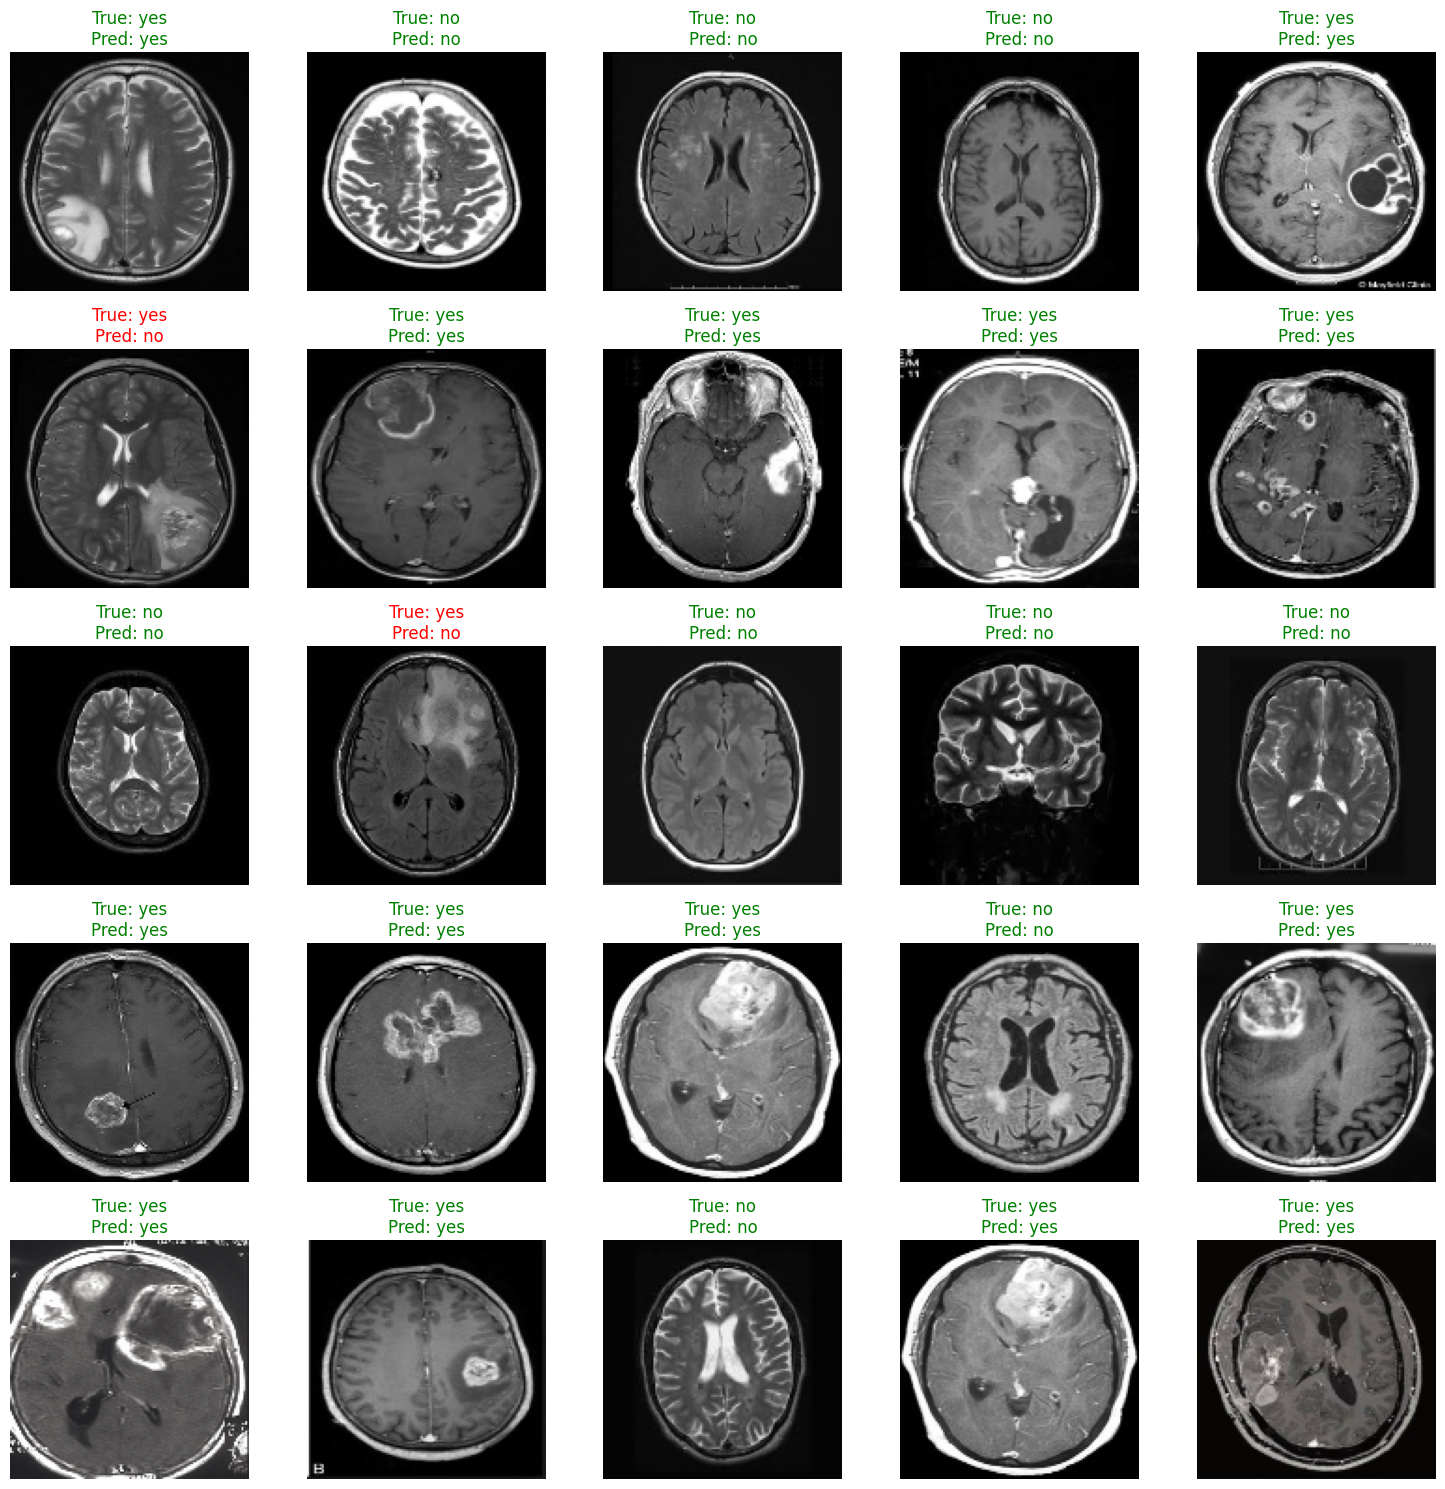

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Number of images to predict and display
num_images_to_display = 25

# Ensure we don't ask for more images than available in the test set
if num_images_to_display > len(X_test):
    num_images_to_display = len(X_test)

# Randomly select indices from the test set
random_indices_test = random.sample(range(len(X_test)), num_images_to_display)

# Get the selected images and their true labels
selected_images = X_test[random_indices_test]
true_labels = y_test[random_indices_test]

# Predict probabilities for the selected images
predicted_probs = model.predict(selected_images).flatten()

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
# Assuming 'yes' corresponds to 1 and 'no' to 0
predicted_labels = (predicted_probs > 0.5).astype(int)

# Create a mapping for numerical labels back to original class names for display
label_map = {0: 'no', 1: 'yes'}

# Plot the images with actual and predicted labels
plt.figure(figsize=(15, 15))
for i in range(num_images_to_display):
    plt.subplot(5, 5, i + 1) # 5 rows, 5 columns
    plt.imshow(selected_images[i])
    true_label_str = label_map[true_labels[i]]
    predicted_label_str = label_map[predicted_labels[i]]

    # Set title color based on correctness of prediction
    title_color = "green" if true_labels[i] == predicted_labels[i] else "red"

    plt.title(f"True: {true_label_str}\nPred: {predicted_label_str}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()